# Influenza Outbreak Prediction via Twitter

In [ ]:
import scipy.io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

In [ ]:
data = scipy.io.loadmat(r"influenza+outbreak+event+prediction+via+twitter\influenza_outbreak_dataset.mat")  

print(data.keys())  

dict_keys(['__header__', '__version__', '__globals__', 'flu_X_tr', 'flu_Y_tr', 'flu_X_te', 'flu_Y_te', 'flu_locs', 'flu_keywords'])


In [ ]:
import os

if not os.path.exists('data'):
    os.makedirs('data')

In [ ]:
def save_keys_to_csv(data):
    for key in data.keys():
        if isinstance(data[key], np.ndarray):
            df_key = pd.DataFrame(data[key])
            df_key.to_csv(f"data/{key}.csv", index=False)
save_keys_to_csv(data)

In [ ]:
flu_X_tr = pd.read_csv("data/flu_X_tr.csv")
flu_X_te = pd.read_csv("data/flu_X_te.csv")
flu_Y_tr = pd.read_csv("data/flu_Y_tr.csv")
flu_Y_te = pd.read_csv("data/flu_Y_te.csv")

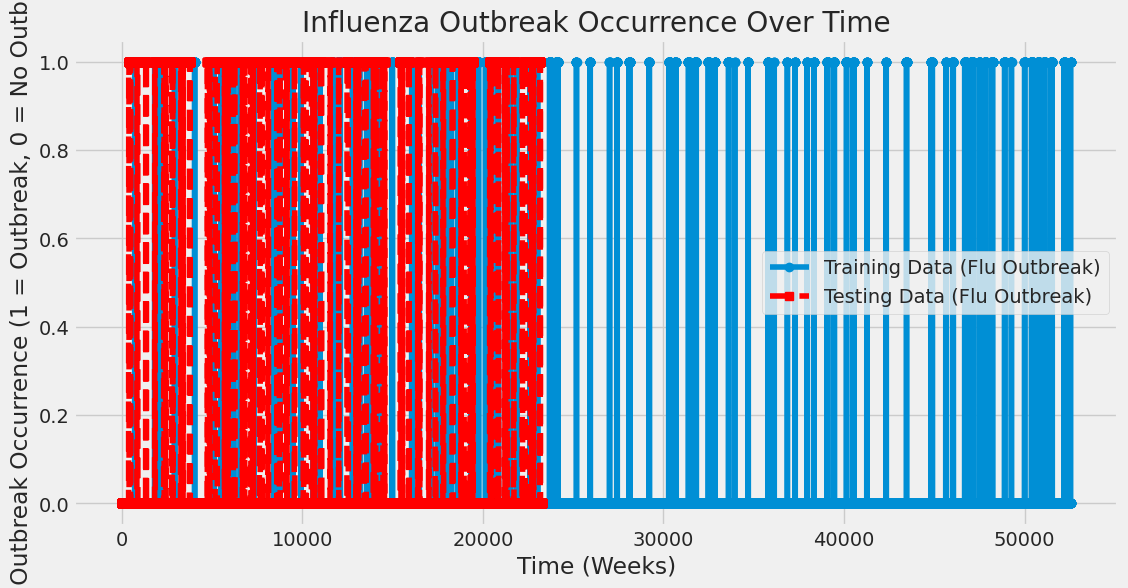

In [ ]:
flu_Y_tr = np.concatenate([arr.flatten() for arr in data["flu_Y_tr"].flatten()])  # Flatten nested arrays
flu_Y_te = np.concatenate([arr.flatten() for arr in data["flu_Y_te"].flatten()])

plt.style.use('fivethirtyeight')
plt.figure(figsize=(12, 6))
plt.plot(range(len(flu_Y_tr)), flu_Y_tr, marker='o', linestyle='-', label="Training Data (Flu Outbreak)")
plt.plot(range(len(flu_Y_te)), flu_Y_te, marker='s', linestyle='--', label="Testing Data (Flu Outbreak)", color='r')

plt.xlabel("Time (Weeks)")
plt.ylabel("Flu Outbreak Occurrence (1 = Outbreak, 0 = No Outbreak)")
plt.title("Influenza Outbreak Occurrence Over Time")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
num_no_outbreak = np.sum(flu_Y_tr == 0)
num_outbreak = np.sum(flu_Y_tr == 1)

ratio = num_no_outbreak / num_outbreak
print(f"Class Imbalance Ratio: {ratio:.2f}:1")

Class Imbalance Ratio: 17.09:1


In [ ]:
flu_Y_tr

array([0, 0, 0, ..., 1, 1, 1], dtype=uint8)

# Converting Sparse Matrix to Dense

## Training data

x_training:rows: 1095 \* 48 = 52560  
x_training:col : 545  
y_training:rows : 1095 \* 48 =52560  
y_training:col : 1


In [ ]:
x_tr=[]
for i in range(48):
  x_tr.append(data['flu_X_tr'][0][i].todense())

x_tr=np.array(x_tr)

x_tr = x_tr.reshape(x_tr.shape[0]*x_tr.shape[1],x_tr.shape[2])
x_tr=pd.DataFrame(x_tr)
x_tr.shape

y_tr=[]

for i in range(48) :
  y_tr.append(data['flu_Y_tr'][0][i])

y_tr=np.array(y_tr)
y_tr = y_tr.reshape(-1,1)
y_tr=pd.DataFrame(y_tr)
x_tr.shape

print("X_tr -"+ str(x_tr.shape))
print("Y_tr -"+ str(y_tr.shape))

X_tr -(52560, 545)
Y_tr -(52560, 1)


## Testing Data

x_test:rows: 485 \* 48 = 23280  
x_test:col : 545  
y_test:rows : 485 \* 48 =23280  
y_test:col : 1


In [ ]:
x_te=[]
for i in range(len(data['flu_X_te'][0])):
   x_te.append(data['flu_X_te'][0][i].todense())
y_te=[]
for i in range(len(data['flu_Y_te'][0])):
   y_te.append(data['flu_Y_te'][0][i])

x_te=np.array(x_te)
y_te=np.array(y_te)

x_te=x_te.reshape(x_te.shape[0]*x_te.shape[1],x_te.shape[2])
y_te=y_te.reshape(y_te.shape[0]*y_te.shape[1],y_te.shape[2])

x_te=pd.DataFrame(x_te)
y_te=pd.DataFrame(y_te)

print('x_te - shape:',x_te.shape)
print('y_te - shape:',y_te.shape)

x_te - shape: (23280, 545)
y_te - shape: (23280, 1)


In [ ]:
x_tr.head()

,0,1,2,3,4,5,6,7,8,9,...,535,536,537,538,539,540,541,542,543,544
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
y_tr.head()

,0
0,0
1,0
2,0
3,0
4,0


# Applying SMOTE


In [ ]:
from imblearn.over_sampling import SMOTE
import numpy as np

smote = SMOTE(sampling_strategy='auto', random_state=42)

X_resampled, Y_resampled = smote.fit_resample(x_tr, y_tr)

unique, counts = np.unique(Y_resampled, return_counts=True)
print("Class Distribution After SMOTE:", dict(zip(unique, counts)))


Class Distribution After SMOTE: {np.uint8(0): np.int64(49655), np.uint8(1): np.int64(49655)}


In [ ]:
X_resampled.shape

(99310, 545)

In [ ]:
scaler = StandardScaler()

In [ ]:
X_resampled_scaled = scaler.fit_transform(X_resampled)
X_test_scaled = scaler.transform(x_te)

# Model Training

## Logistic Regression


In [ ]:
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_reg.fit(X_resampled_scaled, Y_resampled)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [ ]:
y_pred = log_reg.predict(X_test_scaled)
acc = accuracy_score(y_te, y_pred)
print(f"Accuracy: {acc:.2f}")

Accuracy: 0.83


In [ ]:
clf = classification_report(y_te, y_pred)
print(clf)

              precision    recall  f1-score   support

           0       0.95      0.86      0.90     20998
           1       0.29      0.54      0.38      2282

    accuracy                           0.83     23280
   macro avg       0.62      0.70      0.64     23280
weighted avg       0.88      0.83      0.85     23280



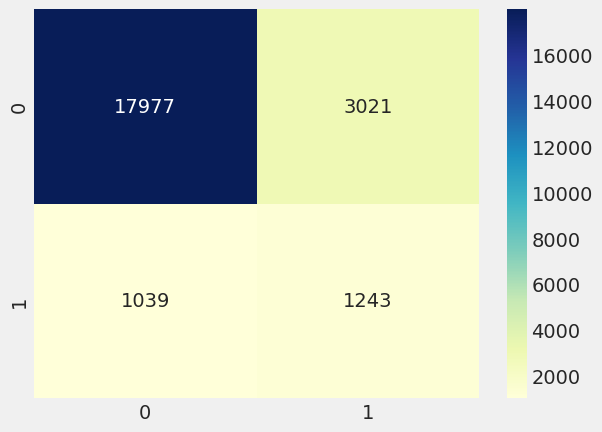

In [ ]:
cm = confusion_matrix(y_te, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu');

## Random Forest


In [ ]:
rf = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)
rf.fit(X_resampled_scaled, Y_resampled)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [ ]:
y_pred_rf = rf.predict(X_test_scaled)
rf_acc = accuracy_score(y_te, y_pred_rf)
print(f"Accuracy:{rf_acc:.2f}")

Accuracy:0.90


In [ ]:
clf = classification_report(y_te, y_pred_rf)
print(clf)

              precision    recall  f1-score   support

           0       0.90      1.00      0.95     20998
           1       0.66      0.03      0.05      2282

    accuracy                           0.90     23280
   macro avg       0.78      0.51      0.50     23280
weighted avg       0.88      0.90      0.86     23280



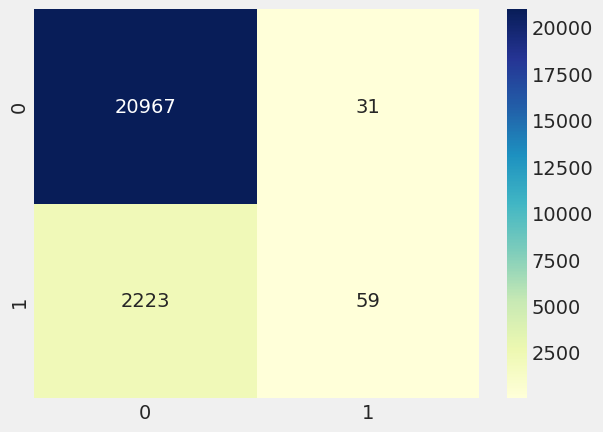

In [ ]:
cm = confusion_matrix(y_te, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu');

# PCA


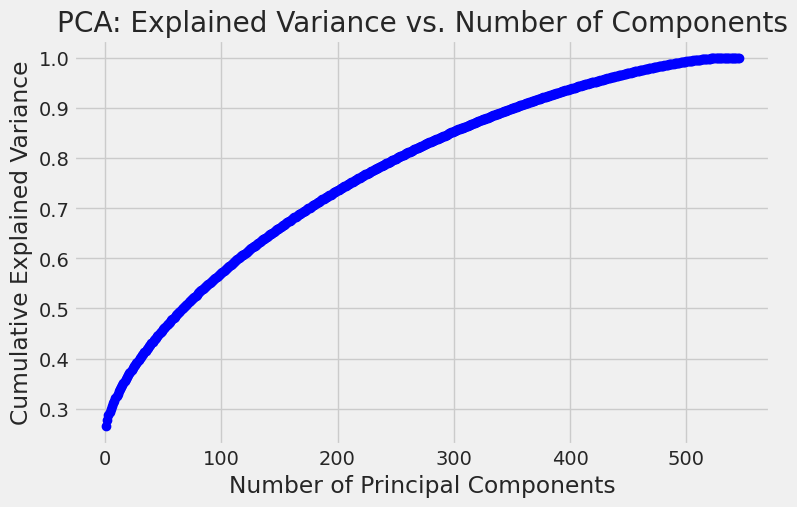

Optimal number of components to retain ~95% variance: 418
Original Shape: (52560, 545)
Reduced Shape: (99310, 418)


In [ ]:
from sklearn.decomposition import PCA
pca = PCA()
X_pca = pca.fit_transform(X_resampled_scaled)


explained_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='--', color='b')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA: Explained Variance vs. Number of Components')
plt.grid(True)
plt.show()

num_components = np.argmax(explained_variance >= 0.95) + 1
print(f"Optimal number of components to retain ~95% variance: {num_components}")

pca = PCA(n_components=num_components)
X_reduced = pca.fit_transform(X_resampled_scaled)

X_reduced_df = pd.DataFrame(X_reduced, columns=[f'PC{i+1}' for i in range(num_components)])

print("Original Shape:", x_tr.shape)
print("Reduced Shape:", X_reduced_df.shape)

# Model Training with PCA


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_reduced_df, Y_resampled, test_size=0.2, random_state=42)


log_reg_pca = LogisticRegression()
rf_model_pca = RandomForestClassifier(n_estimators=100, random_state=42)

log_reg_pca.fit(X_train, y_train)
rf_model_pca.fit(X_train, y_train)

log_reg_pca_pred = log_reg_pca.predict(X_test)
rf_model_pca_pred = rf_model_pca.predict(X_test)

print("Logistic Regression Performance:")
print(classification_report(y_test, log_reg_pca_pred))

print("Random Forest Performance:")
print(classification_report(y_test, rf_model_pca_pred))

Logistic Regression Performance:
              precision    recall  f1-score   support

           0       0.72      0.86      0.78      9915
           1       0.82      0.67      0.74      9947

    accuracy                           0.76     19862
   macro avg       0.77      0.76      0.76     19862
weighted avg       0.77      0.76      0.76     19862

Random Forest Performance:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96      9915
           1       0.98      0.94      0.96      9947

    accuracy                           0.96     19862
   macro avg       0.96      0.96      0.96     19862
weighted avg       0.96      0.96      0.96     19862



# RNN


Epoch 1/20
3104/3104 ━━━━━━━━━━━━━━━━━━━━ 23s 6ms/step - accuracy: 0.7581 - loss: 0.4986 - val_accuracy: 0.8669 - val_loss: 0.4236
Epoch 2/20
3104/3104 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - accuracy: 0.8871 - loss: 0.2655 - val_accuracy: 0.8343 - val_loss: 0.6222
Epoch 3/20
3104/3104 ━━━━━━━━━━━━━━━━━━━━ 39s 7ms/step - accuracy: 0.9173 - loss: 0.1972 - val_accuracy: 0.8732 - val_loss: 0.6245
Epoch 4/20
3104/3104 ━━━━━━━━━━━━━━━━━━━━ 40s 7ms/step - accuracy: 0.9312 - loss: 0.1662 - val_accuracy: 0.8881 - val_loss: 0.6331
Epoch 5/20
3104/3104 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - accuracy: 0.9380 - loss: 0.1509 - val_accuracy: 0.8857 - val_loss: 0.8012
Epoch 6/20
3104/3104 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - accuracy: 0.9422 - loss: 0.1410 - val_accuracy: 0.8807 - val_loss: 0.8641
Epoch 7/20
3104/3104 ━━━━━━━━━━━━━━━━━━━━ 35s 6ms/step - accuracy: 0.9470 - loss: 0.1293 - val_accuracy: 0.8744 - val_loss: 0.8347
Epoch 8/20
3104/3104 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.9504 - loss: 0

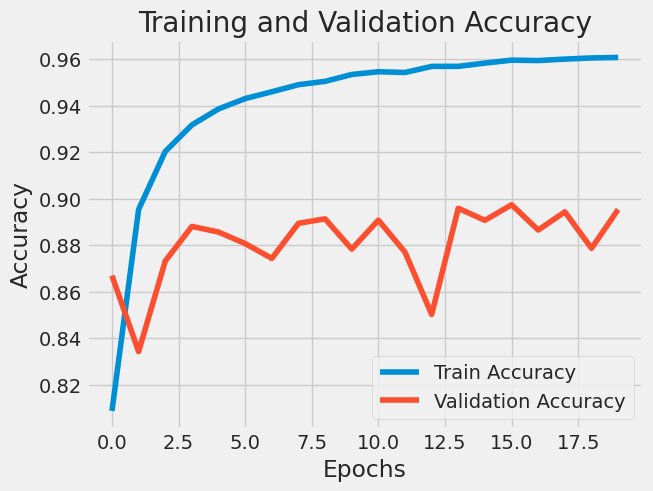

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, Dropout
from tensorflow.keras.utils import to_categorical


X_train_rnn = X_resampled_scaled.reshape((X_resampled_scaled.shape[0], 1, X_resampled_scaled.shape[1]))
X_test_rnn = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

Y_train_rnn = to_categorical(Y_resampled)
Y_test_rnn = to_categorical(y_te)

model = Sequential([
    SimpleRNN(128, activation='relu', input_shape=(X_train_rnn.shape[1], X_train_rnn.shape[2])),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(Y_train_rnn.shape[1], activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(X_train_rnn, Y_train_rnn, epochs=20, batch_size=32, validation_data=(X_test_rnn, Y_test_rnn))

loss, accuracy = model.evaluate(X_test_rnn, Y_test_rnn)
print(f"Test Accuracy: {accuracy:.2f}")

import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()


# LSTM


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical


X_train_lstm = X_resampled_scaled.reshape((X_resampled_scaled.shape[0], 1, X_resampled_scaled.shape[1]))
X_test_lstm = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

Y_train_lstm = to_categorical(Y_resampled)
Y_test_lstm = to_categorical(y_te)

model = Sequential([
    LSTM(128, activation='relu', input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(Y_train_lstm.shape[1], activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(X_train_lstm, Y_train_lstm, epochs=20, batch_size=32, validation_data=(X_test_lstm, Y_test_lstm))

loss, accuracy = model.evaluate(X_test_lstm, Y_test_lstm)
print(f"Test Accuracy: {accuracy:.2f}")


Epoch 1/20
3104/3104 ━━━━━━━━━━━━━━━━━━━━ 68s 18ms/step - accuracy: 0.7929 - loss: 0.4473 - val_accuracy: 0.8622 - val_loss: 0.5640
Epoch 2/20
3104/3104 ━━━━━━━━━━━━━━━━━━━━ 69s 14ms/step - accuracy: 0.9183 - loss: 0.1957 - val_accuracy: 0.8729 - val_loss: 0.8344
Epoch 3/20
3104/3104 ━━━━━━━━━━━━━━━━━━━━ 78s 13ms/step - accuracy: 0.9383 - loss: 0.1479 - val_accuracy: 0.8646 - val_loss: 1.0065
Epoch 4/20
3104/3104 ━━━━━━━━━━━━━━━━━━━━ 35s 11ms/step - accuracy: 0.9463 - loss: 0.1298 - val_accuracy: 0.8930 - val_loss: 1.0675
Epoch 5/20
3104/3104 ━━━━━━━━━━━━━━━━━━━━ 39s 13ms/step - accuracy: 0.9501 - loss: 0.1206 - val_accuracy: 0.8888 - val_loss: 1.3134
Epoch 6/20
3104/3104 ━━━━━━━━━━━━━━━━━━━━ 39s 12ms/step - accuracy: 0.9545 - loss: 0.1079 - val_accuracy: 0.8677 - val_loss: 1.3444
Epoch 7/20
3104/3104 ━━━━━━━━━━━━━━━━━━━━ 40s 12ms/step - accuracy: 0.9563 - loss: 0.1049 - val_accuracy: 0.8887 - val_loss: 1.3782
Epoch 8/20
3104/3104 ━━━━━━━━━━━━━━━━━━━━ 45s 13ms/step - accuracy: 0.9587 -